# Q-Learning on MountainCar-v0

This notebook implements a **model-free** reinforcement learning solution for MountainCar using **tabular Q-learning**. The notebook is organized into three main parts:

1. **State Discretization** — The MountainCar environment has a continuous state space (position and velocity). We discretize it into a finite grid of bins so we can represent and update a tabular Q-table.
2. **Q-Learning Training Loop** — The agent interacts with the environment over many episodes, updating Q-values online using the Q-learning rule with an epsilon-greedy exploration strategy.
3. **Policy Extraction and Evaluation** — After training, we extract the greedy policy from the Q-table and visualize both the learned value function and the resulting policy.

In [14]:
import numpy as np # used for arrays
import gymnasium as gym # pull the environment
from tqdm import tqdm # used for progress bar

## Environment Setup

Here we instantiate the MountainCar environment and inspect its action space.
`gym.make("MountainCar-v0")` loads the environment; `env.action_space.n` tells us how many discrete actions exist (3: push left, no push, push right).

In [15]:
env = gym.make("MountainCar-v0")
print(env.action_space.n)

3


In [16]:
LEARNING_RATE = 0.9

DISCOUNT = 0.95
EPISODES = 10000
total = 0
total_reward = 0
prior_reward = 0

# given hyperparams
epsilon = 0.5
start_epsilon_decay = 1
end_epsilon_decay = EPISODES // 2
epsilon_decay_value = epsilon / (end_epsilon_decay - start_epsilon_decay)

## Discretization: Mapping Continuous States to Discrete Bins

Many RL environments have **continuous** state spaces, but tabular methods like Q-learning require **discrete** integer indices. **Discretization** solves this by dividing each continuous dimension into equally-sized bins and mapping each value to a bin index.

**Formula:** `bin_index = floor((value - low) / bin_width)` where `bin_width = (high - low) / num_bins`

**Two important nuances to implement correctly:**

1. **Use `.astype(int)` (floor), not `np.round()`:**  
   `(value - low) / bin_width` produces a float like `26.67`. You want bin `26` — the bin the value *falls into* — not bin `27`. `.astype(int)` drops the decimal, which gives you the correct bin. Using `np.round()` would incorrectly push near-boundary values into the next bin.

2. **Clip to avoid an out-of-bounds index:**  
   When `value` is exactly at the upper boundary, the formula gives `index = num_bins`, which is one past the last valid index (`num_bins - 1`) and will cause an `IndexError`. Add one line after computing the bin index:
   ```python
   discrete_state = np.clip(discrete_state, 0, obs_bins - 1)
   ```

**Example** (MountainCar position dimension, 40 bins):
- MountainCar state space: position ∈ [-1.2, 0.6], velocity ∈ [-0.07, 0.07]
- `bin_width = (0.6 − (−1.2)) / 40 = 0.045`
- position = 0.0 → `(0.0 − (−1.2)) / 0.045 = 26.67` → **bin 26**
- position = 0.6 (max) → `1.8 / 0.045 = 40.0` → clip to **bin 39**

---

**Your Task:** The next three code cells set up the discretized state representation. Fill in the following:

1. **`obs_bins`** — Choose the number of bins for the position and velocity dimensions.
2. **`discrete_window_size`** — Compute the bin width for each dimension using the formula above.
3. **`q_shape`** — Define the shape of the Q-table as `(pos_bins, vel_bins, num_actions)`.
4. **`get_discrete_state(state)`** — Apply the discretization formula to map a continuous `[position, velocity]` state to integer bin indices.

In [17]:
# TODO: Replace None with the number of bins for each dimension of the state space.
# obs_bins should be a tuple (num_position_bins, num_velocity_bins).
obs_bins = (20, 20)

# TODO: Replace None with the bin width for each dimension.
# discrete_window_size is derived from the observation space range and the number of bins.
# Refer to the discretization formula in the markdown cell above.
discrete_window_size = (env.observation_space.high - env.observation_space.low) / np.array(obs_bins)

In [18]:
# TODO: Replace None with the correct shape for the Q-table.
# q_shape should be a tuple: (number of position bins, number of velocity bins, number of actions).
q_shape = (obs_bins[0], obs_bins[1], env.action_space.n)
q_table = np.random.uniform(low=-2, high=0, size=q_shape)
q_shape


(20, 20, np.int64(3))

In [19]:
# TODO: Replace None with the discretized state.
# Use the discretization formula described in the markdown cell above to map
# the continuous state (position, velocity) to integer bin indices.
# Make sure to handle edge cases so indices stay within valid bounds.
def get_discrete_state(state):
    discrete_state = (np.array(state) - env.observation_space.low) / discrete_window_size
    discrete_state = np.clip(discrete_state, 0, np.array(obs_bins) - 1)
    return tuple(discrete_state.astype(int))

## Training Loop: Epsilon-Greedy Q-Learning

During training the agent must balance **exploration** (trying random actions to discover better strategies) vs. **exploitation** (using the best known action). We use an **epsilon-greedy** policy:
- With probability `epsilon`: choose a **random** action (explore)
- With probability `1 - epsilon`: choose `argmax Q[s, :]` (exploit)

Epsilon starts at 0.5 and **linearly decays** to 0 over the first half of training, so the agent explores heavily early on, then increasingly exploits as the Q-table matures.

**Q-learning update rule** (apply when the episode is not done):
```
Q[s, a] += learning_rate * (reward + discount * max(Q[s']) - Q[s, a])
```
Note: when the goal is reached (`new_state[0] >= 0.5`), the reward is 0 and there is no future state, so we set `Q[s, a] = 0` directly (already provided).

---

**Your Task:** Fill in two parts of the training loop:

1. **Epsilon-greedy action selection:**
   - **Exploit** (`np.random.random() > epsilon`): Select the greedy action for `discrete_state` using `np.argmax`.
   - **Explore** (otherwise): Sample a random action from the action space using `np.random.randint`.

2. **Q-learning update** (inside `if not done`): Apply the update rule above to update `q_table[discrete_state + (action,)]`.

In [20]:
ep_rewards = []

for ep in tqdm(range(EPISODES)):
    done = False
    truncated = False
    discrete_state = get_discrete_state(env.reset()[0])  # initial discrete state


    ep_reward = 0
    while not done and not truncated:  # goal reached means reward = 0

        # TODO: Fill in epsilon-greedy action selection.
        if np.random.random() > epsilon:
            # TODO: Replace None with the greedy action (the action with the highest Q-value for the current state).
            action = np.argmax(q_table[discrete_state])
        else:
            # TODO: Replace None with a random action sampled from the environment's action space.
            action = np.random.randint(0, env.action_space.n)

        # Run one timestep of the environment's dynamics;  returns a tuple (observation, reward, done, info).
        new_state, reward, done, truncated, _ = env.step(action)
        ep_reward += reward

        new_discrete_state = get_discrete_state(new_state)


        # TODO: Implement the Q-learning update for the current (state, action, reward, new_state) transition.
        # Use the Q-learning update rule described in the markdown cell above.
        # Update q_table at the current discrete_state and action.
        if not done:
            pos, vel = discrete_state
            new_pos, new_vel = new_discrete_state
            
            current_q = q_table[pos, vel, action]
            td_target = reward + DISCOUNT * np.max(q_table[new_pos, new_vel])
            td_error = td_target - current_q
            
            q_table[pos, vel, action] = current_q + LEARNING_RATE * td_error
            

        # goal reached; reward = 0
        elif new_state[0] >= 0.5:
            q_table[discrete_state + (action, )] = 0

        discrete_state = new_discrete_state
    ep_rewards.append(ep_reward)

    if end_epsilon_decay >= ep >= start_epsilon_decay:
        epsilon -= epsilon_decay_value


env.close()

100%|██████████| 10000/10000 [00:25<00:00, 395.73it/s]


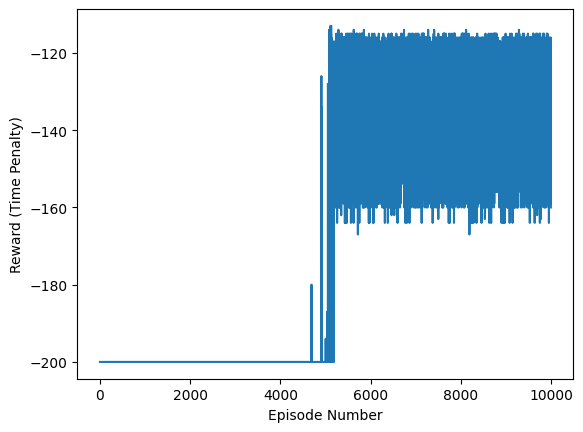

In [21]:
import matplotlib.pyplot as plt

plt.plot(ep_rewards)
plt.ylabel('Reward (Time Penalty)')
plt.xlabel('Episode Number')
plt.show()

**Interpretation:** Reward is always **negative** in MountainCar. A reward closer to 0 means the agent reached the goal faster. You should observe:
- **Early episodes:** rewards are large negative values (agent times out every episode)
- **After epsilon decays** (around episode 5000): rewards improve (less negative) as the agent exploits its learned Q-values
- **Some noise/variance is normal** — stochastic exploration and within-bin sampling cause variation

Visualize Q-Table (No Coding Required Below)

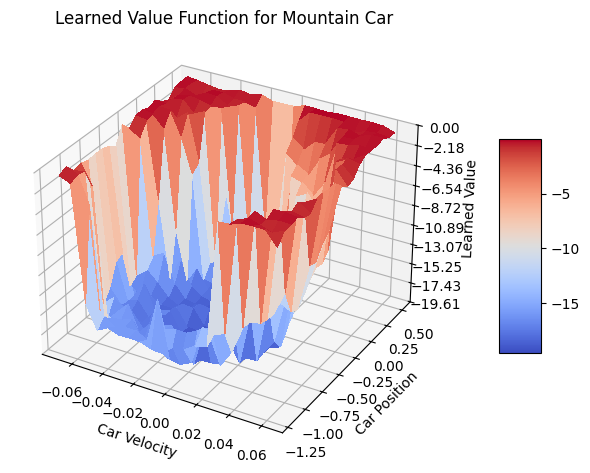

In [22]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

# max Q over possible actions
q_viz = q_table.max(axis=(-1))

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
X = np.arange(env.observation_space.low[1], env.observation_space.high[1], discrete_window_size[1])
Y = np.arange(env.observation_space.low[0], env.observation_space.high[0], discrete_window_size[0])
X, Y = np.meshgrid(X, Y)

# Plot the surface.
surf = ax.plot_surface(X, Y, q_viz, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(np.min(q_viz), np.max(q_viz))
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

ax.set_xlabel('Car Velocity')
ax.set_ylabel('Car Position')
ax.set_zlabel('Learned Value')
ax.set_title('Learned Value Function for Mountain Car')

# Add a color bar which maps values to colors.
# fig.set_size_inches(10, 8)
fig.colorbar(surf, shrink=0.5, aspect=5, pad=0.1)
fig.tight_layout()

plt.show()

## Extract Policy

**Your Task:** Derive the greedy policy from the learned Q-table:

- **`policy`** — A `(pos_bins, vel_bins)` array where each entry is the action with the highest Q-value for that state. Use `np.argmax`.

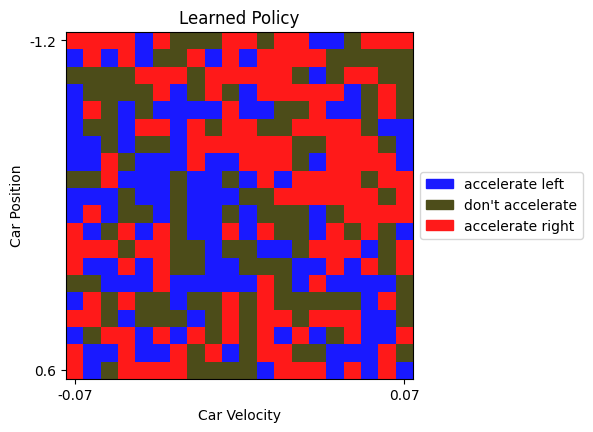

In [23]:
import matplotlib.patches as mpatches

# TODO: Replace None with the policy array.
# policy should be a (pos_bins, vel_bins) array where each entry is the best action
# (the one with the highest Q-value) for that state.
policy = np.argmax(q_table, axis=2)

# define cmap, patches and convert
cmap = {0:[0.1,0.1,1.0,1],1:[0.3,0.3,0.1,1],2:[1.0,0.1,0.1,1]}
labels = {0:'accelerate left',1:'don\'t accelerate',2:'accelerate right'}
p_viz = np.array([[cmap[policy[i,j]] for j in range(q_shape[1])] for i in range(q_shape[0])])
patches =[mpatches.Patch(color=cmap[i],label=labels[i]) for i in cmap]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(p_viz)
plt.ylabel('Car Position')
plt.xlabel('Car Velocity')
plt.xticks([0, q_shape[1]-1],
           [env.observation_space.low[1], env.observation_space.high[1]])
plt.yticks([0, q_shape[0]-1],
           [env.observation_space.low[0], env.observation_space.high[0]])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), handles=patches)

ax.set_title("Learned Policy")
fig.tight_layout()
plt.show()

## Use Policy (outputs a video, watch your agent play!)

**Your Task:** Fill in the action selection inside the evaluation loop:

- **`action`** — Select the greedy action for the current `discrete_state` from the learned Q-table. Use `np.argmax`.

In [24]:
from gymnasium.wrappers import RecordVideo
from datetime import datetime

test_env = gym.make("MountainCar-v0", render_mode="rgb_array")
test_env = RecordVideo(test_env, video_folder="./video", video_length=1000, disable_logger=True,
                       name_prefix=f"q_learning_{datetime.now().strftime('%Y%m%d_%H%M%S')}")

# play the game with the learned policy
done = False
truncated = False
discrete_state = get_discrete_state(test_env.reset()[0])
while not done and not truncated:
    # TODO: Replace None with the greedy action from the learned Q-table for the current discrete_state.
    action = np.argmax(q_table[discrete_state])
    new_state, reward, done, truncated, _ = test_env.step(action)
    discrete_state = get_discrete_state(new_state)

test_env.close()

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at f:\UMich\W26\EECS 492\Homework4\video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
